List Pertanyaan untuk mendalami EDA ini :

1. Bagaimana tren penjualan harian berdasarkan total sales?
2. Produk apa yang memiliki total penjualan tertinggi?
3. Store mana yang menghasilkan penjualan terbesar?
4. Apakah terdapat hari dengan penjualan tidak normal (outlier)?
5. Bagaimana distribusi quantity dan sales?
6. Apakah terdapat perbedaan pola penjualan antar produk?
7. Apakah outlier berpengaruh terhadap hasil analisis?

1. kita import dulu library library yang di butuhkan 
kita butuh pandas, matplotlib dengan library read csv file karena file nya csv. 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_csv("dataset/sales1.csv")
    print("Data Berhasil Masuk")
except FileNotFoundError:
    print("File tidak ditemukan")

df['date'] = pd.to_datetime(df['date'], format="%d/%m/%Y")

Data Berhasil Masuk


- `pandas` digunakan untuk membaca dan mengolah dataset
- `matplotlib` digunakan untuk visualisasi data
- File CSV dibaca menggunakan `read_csv`
- Kolom `date` dikonversi ke format datetime agar bisa dianalisis berdasarkan waktu

## Pertanyaan 1
Bagaimana tren penjualan harian berdasarkan total sales?

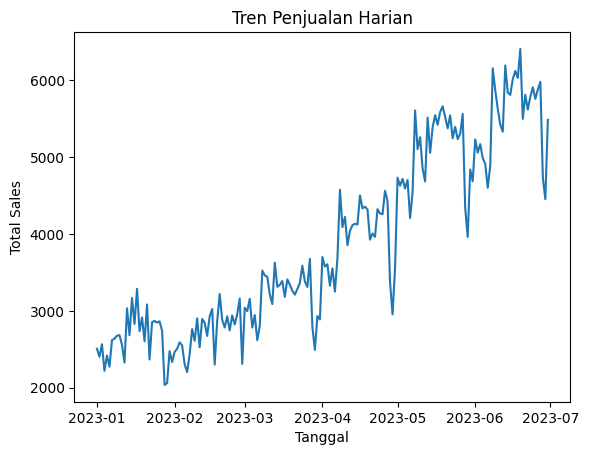

In [5]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()
daily_sales

plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title("Tren Penjualan Harian")
plt.xlabel("Tanggal")
plt.ylabel("Total Sales")
plt.show()

### Penjelasan

Analisis ini bertujuan untuk mengetahui pola penjualan berdasarkan waktu, khususnya untuk melihat apakah penjualan cenderung stabil atau mengalami fluktuasi dari hari ke hari.

### Library yang Digunakan
- pandas  
Digunakan untuk melakukan pengolahan dan agregasi data.

- matplotlib  
Digunakan untuk memvisualisasikan tren penjualan dalam bentuk grafik garis.

### Fungsi yang Digunakan
- `groupby('date')`  
Digunakan untuk mengelompokkan data berdasarkan tanggal transaksi.

- `sum()`  
Digunakan untuk menjumlahkan total nilai penjualan per tanggal.

- `reset_index()`  
Digunakan untuk mengubah index hasil groupby menjadi kolom kembali agar mudah dianalisis.

- `plt.plot()`  
Digunakan untuk membuat grafik garis yang menunjukkan perubahan penjualan dari waktu ke waktu.

Hasil analisis menunjukkan bahwa total penjualan harian bersifat fluktuatif. Pada beberapa tanggal tertentu terlihat lonjakan penjualan yang cukup signifikan, yang mengindikasikan adanya hari dengan aktivitas transaksi yang lebih tinggi dibanding hari lainnya.

## Pertanyaan 2
Produk apa yang memiliki total penjualan tertinggi?

In [6]:
product_sales = df.groupby('product')['sales'].sum().reset_index()
product_sales = product_sales.sort_values(by='sales', ascending=False)
product_sales.head()

,product,sales
0,Barista Espresso,91406.20
4,Brewed Chai tea,77081.95
17,Hot chocolate,72416.00
13,Gourmet brewed coffee,70034.60
3,Brewed Black tea,47932.00


### Penjelasan

Analisis ini dilakukan untuk mengidentifikasi produk yang memberikan kontribusi terbesar terhadap total penjualan.

### Library yang Digunakan
- pandas  
Digunakan untuk mengelompokkan dan mengurutkan data berdasarkan produk.

### Fungsi yang Digunakan
- `groupby('product')`  
Digunakan untuk mengelompokkan data berdasarkan nama produk.

- `sum()`  
Digunakan untuk menghitung total penjualan setiap produk.

- `sort_values()`  
Digunakan untuk mengurutkan data berdasarkan total sales dari yang tertinggi.


Terlihat bahwa hanya beberapa produk yang mendominasi total penjualan. Produk dengan total sales tertinggi dapat dikategorikan sebagai produk unggulan dengan tingkat permintaan yang lebih tinggi.

## Pertanyaan 3
Store mana yang menghasilkan penjualan terbesar?

In [7]:
store_sales = df.groupby('store')['sales'].sum().reset_index()
store_sales.sort_values(by='sales', ascending=False)

,store,sales
1,Hell's Kitchen,236511.17
0,Astoria,232243.91
2,Lower Manhattan,230057.25


### Penjelasan
Analisis ini bertujuan untuk membandingkan performa penjualan antar store.

### Library yang Digunakan
- pandas

### Fungsi yang Digunakan
- `groupby('store')`  
Digunakan untuk mengelompokkan data berdasarkan lokasi store.

- `sum()`  
Digunakan untuk menghitung total penjualan per store.

Hasil analisis menunjukkan bahwa terdapat store dengan total penjualan yang jauh lebih tinggi dibanding store lainnya. Hal ini mengindikasikan perbedaan performa lokasi penjualan.

## Pertanyaan 4
Apakah terdapat hari dengan penjualan tidak normal (outlier)?

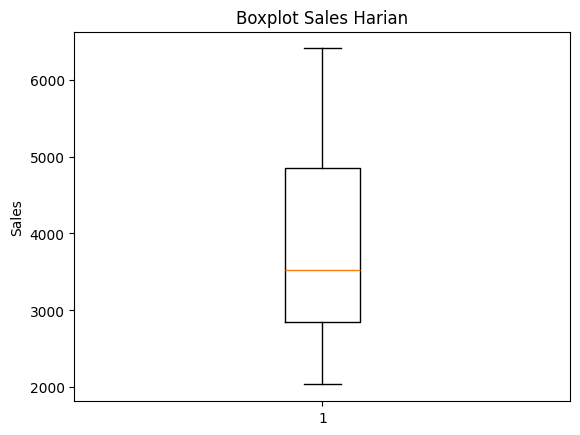

In [8]:
plt.boxplot(daily_sales['sales'])
plt.title("Boxplot Sales Harian")
plt.ylabel("Sales")
plt.show()

### Penjelasan

Analisis ini dilakukan untuk mendeteksi adanya penjualan ekstrem yang berpotensi menjadi outlier.

### Library yang Digunakan
- matplotlib  
Digunakan untuk visualisasi distribusi data menggunakan boxplot.

### Fungsi yang Digunakan
- `plt.boxplot()`  
Digunakan untuk menampilkan sebaran data dan mendeteksi nilai ekstrem.

### Interpretasi Hasil
Boxplot menunjukkan adanya nilai penjualan harian yang berada di luar rentang utama data, yang mengindikasikan adanya hari dengan penjualan tidak normal.

## Pertanyaan 5
Bagaimana distribusi quantity dan sales?

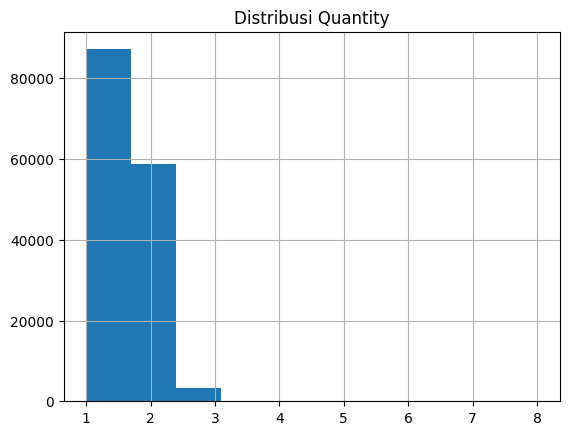

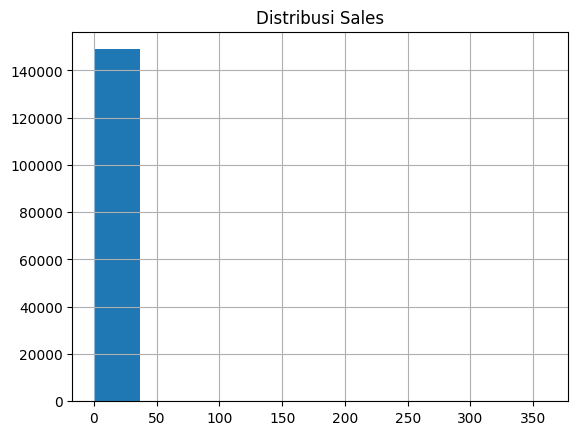

In [9]:
df['quantity'].hist()
plt.title("Distribusi Quantity")
plt.show()

df['sales'].hist()
plt.title("Distribusi Sales")
plt.show()

### Penjelasan
Analisis ini bertujuan untuk memahami pola distribusi data quantity dan sales.

### Library yang Digunakan
- matplotlib

### Fungsi yang Digunakan
- `hist()`  
Digunakan untuk menampilkan distribusi data dalam bentuk histogram.

### Interpretasi Hasil
Distribusi data menunjukkan pola tidak simetris, di mana sebagian besar transaksi bernilai kecil namun terdapat beberapa transaksi bernilai besar.

## Pertanyaan 6
Apakah terdapat perbedaan pola penjualan antar produk?|

In [10]:
df.groupby('product')['sales'].mean().reset_index()

,product,sales
0,Barista Espresso,5.572529
1,Biscotti,3.465861
2,Black tea,8.950000
3,Brewed Black tea,4.223084
4,Brewed Chai tea,4.485943
5,Brewed Green tea,4.206048
6,Brewed herbal tea,4.227612
7,Chai tea,9.709368
8,Clothing,27.886878
9,Drinking Chocolate,10.255789


### Penjelasan

Analisis ini dilakukan untuk melihat perbedaan rata-rata penjualan antar produk.

### Library yang Digunakan
- pandas

### Fungsi yang Digunakan
- `groupby('product')`  
Digunakan untuk mengelompokkan data berdasarkan produk.

- `mean()`  
Digunakan untuk menghitung nilai rata-rata penjualan setiap produk.

### Interpretasi Hasil
Hasil analisis menunjukkan adanya perbedaan pola penjualan antar produk, yang mengindikasikan bahwa setiap produk memiliki karakteristik penjualan yang berbeda.

## Pertanyaan 7
Apakah outlier berpengaruh terhadap hasil analisis?

In [11]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outlier = df[(df['sales'] >= lower) & (df['sales'] <= upper)]

df['sales'].mean(), df_no_outlier['sales'].mean()

(np.float64(4.6863671906435265), np.float64(4.356563839196944))

### Penjelasan

Analisis ini bertujuan untuk melihat dampak outlier terhadap hasil analisis penjualan.

### Library yang Digunakan
- pandas

### Fungsi yang Digunakan
- `quantile()`  
Digunakan untuk menghitung kuartil data.

- Operasi IQR  
Digunakan untuk menentukan batas bawah dan atas outlier.

### Interpretasi Hasil
Setelah dilakukan penghapusan outlier, nilai rata-rata penjualan mengalami perubahan. Hal ini menunjukkan bahwa outlier memiliki pengaruh yang signifikan terhadap hasil analisis.

## Kesimpulan

Melalui pengerjaan tugas Exploratory Data Analysis (EDA) ini, saya mulai memahami bahwa EDA bukan hanya sekadar membuat grafik, tetapi merupakan proses untuk mengenali karakteristik data secara menyeluruh sebelum dilakukan analisis lebih lanjut.

EDA membantu saya dalam:
- memahami pola data
- melihat tren dan perbedaan antar kelompok data
- mendeteksi anomali atau nilai ekstrem (outlier)
- menentukan metode analisis yang sesuai dengan kondisi data

---

### Pemahaman Mengenai Outlier dan Metode IQR

Dalam analisis ini, saya mulai memahami konsep **outlier**, yaitu data yang memiliki nilai jauh berbeda dibandingkan mayoritas data lainnya. Outlier dapat mempengaruhi hasil analisis, terutama pada perhitungan nilai rata-rata dan agregasi data.

Metode **Interquartile Range (IQR)** digunakan untuk mendeteksi outlier karena data penjualan cenderung tidak berdistribusi normal.

Komponen utama dalam metode IQR meliputi:
- **Q1 (Kuartil 1)**: nilai yang membatasi 25% data terbawah
- **Q3 (Kuartil 3)**: nilai yang membatasi 25% data teratas
- **IQR (Interquartile Range)**: selisih antara Q3 dan Q1

Batas outlier ditentukan menggunakan rumus:
- Batas bawah = Q1 − 1.5 × IQR  
- Batas atas = Q3 + 1.5 × IQR  

Dengan menggunakan metode ini, saya dapat melihat bagaimana penghapusan outlier mempengaruhi hasil analisis dan memahami pentingnya mempertimbangkan keberadaan data ekstrem.

---

### Refleksi Pembelajaran

Melalui proses eksplorasi data, saya tidak hanya belajar menggunakan library seperti `pandas` dan `matplotlib`, tetapi juga belajar berpikir analitis dalam membaca data.

Pendekatan eksploratif ini membantu saya memahami bahwa tidak semua data dapat dianalisis dengan satu metode yang sama, dan pemilihan metode harus disesuaikan dengan karakteristik data dan tujuan analisis.